In [41]:
# Install all required libraries

!pip -q install kaggle
!pip -q install opencv-python
!pip -q install scikit-image
!pip -q install pandas
!pip -q install matplotlib
!pip -q install numpy

In [42]:
# Upload kaggle.json file

from google.colab import files

print("Select kaggle.json")

files.upload()

Select kaggle.json


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mrudulaambare","key":"282f4d3638caa5d58a39ecfe521b42ef"}'}

In [43]:
# Configure Kaggle API

import os
import shutil

os.makedirs("/root/.kaggle", exist_ok=True)

shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")

os.chmod("/root/.kaggle/kaggle.json", 600)

print("Kaggle API configured successfully")

Kaggle API configured successfully


In [44]:
# Download the 11K Hands Dataset

!kaggle datasets download -d shyambhu/hands-and-palm-images-dataset

Dataset URL: https://www.kaggle.com/datasets/shyambhu/hands-and-palm-images-dataset
License(s): DbCL-1.0
hands-and-palm-images-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [45]:
# Extract dataset

import zipfile

zip_file = "hands-and-palm-images-dataset.zip"

extract_path = "/content/11K_Hands"

with zipfile.ZipFile(zip_file, "r") as zip_ref:

    zip_ref.extractall(extract_path)

print("Dataset extracted successfully")

Dataset extracted successfully


In [46]:
# Import required libraries

import os
import glob
import random

import cv2
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [47]:
# Locate metadata file

csv_files = glob.glob(
    os.path.join(extract_path, "**", "*.csv"),
    recursive=True
)

metadata = pd.read_csv(csv_files[0])

print(metadata.columns)

metadata.head()

Index(['id', 'age', 'gender', 'skinColor', 'accessories', 'nailPolish',
       'aspectOfHand', 'imageName', 'irregularities'],
      dtype='object')


,id,age,gender,skinColor,accessories,nailPolish,aspectOfHand,imageName,irregularities
0,0,27,male,fair,0,0,dorsal right,Hand_0000002.jpg,0
1,0,27,male,fair,0,0,dorsal right,Hand_0000003.jpg,0
2,0,27,male,fair,0,0,dorsal right,Hand_0000004.jpg,0
3,0,27,male,fair,0,0,dorsal right,Hand_0000005.jpg,0
4,0,27,male,fair,0,0,dorsal right,Hand_0000006.jpg,0


In [48]:
# Select only front side (palmar) hand images

palm_metadata = metadata[
    metadata["aspectOfHand"]
    .str.lower()
    .str.contains("palmar")
].reset_index(drop=True)

print("Total Palm Images :", len(palm_metadata))

Total Palm Images : 5396


In [49]:
# Locate all JPG images

image_files = glob.glob(
    os.path.join(extract_path, "**", "*.jpg"),
    recursive=True
)

print("Total Images :", len(image_files))

Total Images : 11076


In [50]:
# Create a dictionary for quick image lookup

image_lookup = {}

for image_path in image_files:

    filename = os.path.basename(image_path)

    image_lookup[filename] = image_path

print("Image dictionary created")

Image dictionary created


In [51]:
# Randomly select one palm image

random_index = random.randint(
    0,
    len(palm_metadata)-1
)

image_name = palm_metadata.iloc[random_index]["imageName"]

image_path = image_lookup.get(image_name)

print(image_name)

Hand_0000184.jpg


In [52]:
# Randomly select one palm image

random_index = random.randint(
    0,
    len(palm_metadata)-1
)

image_name = palm_metadata.iloc[random_index]["imageName"]

image_path = image_lookup.get(image_name)

print(image_name)

Hand_0001411.jpg


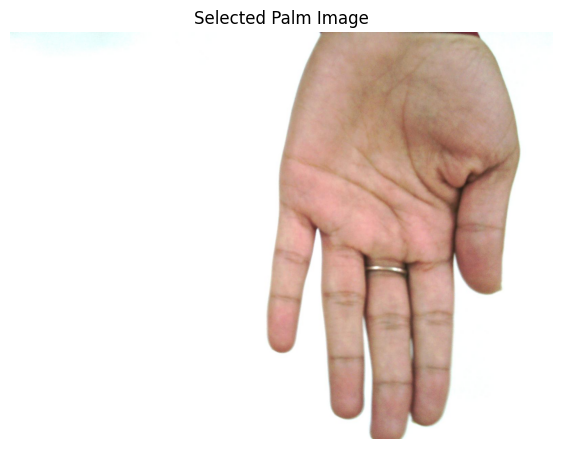

In [53]:
# Display selected palm image

image = cv2.imread(image_path)

image = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(7,7))

plt.imshow(image)

plt.title("Selected Palm Image")

plt.axis("off")

plt.show()

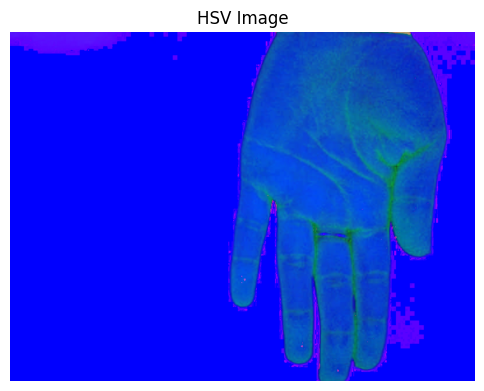

In [54]:
# Convert RGB image to HSV color space

hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

plt.figure(figsize=(6,6))
plt.imshow(hsv)
plt.title("HSV Image")
plt.axis("off")
plt.show()

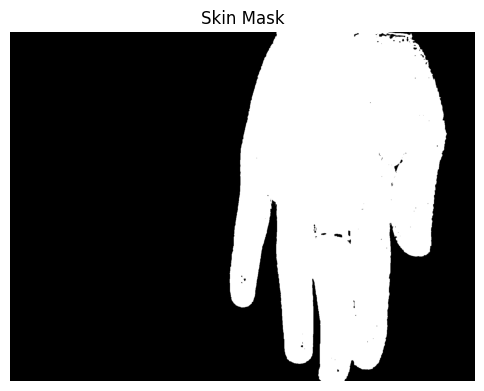

In [55]:
# Create a skin color mask

lower_skin = np.array([0, 20, 60], dtype=np.uint8)
upper_skin = np.array([20, 150, 255], dtype=np.uint8)

skin_mask = cv2.inRange(hsv, lower_skin, upper_skin)

plt.figure(figsize=(6,6))
plt.imshow(skin_mask, cmap="gray")
plt.title("Skin Mask")
plt.axis("off")
plt.show()

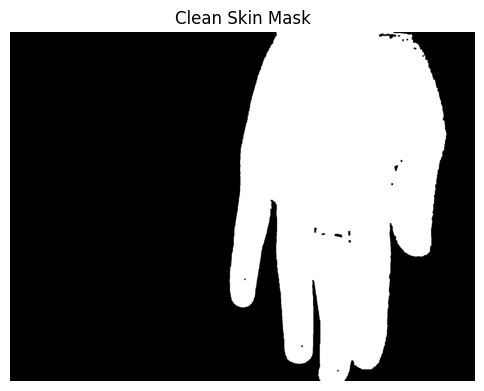

In [56]:
# Remove small noisy regions

kernel = np.ones((5,5), np.uint8)

skin_mask = cv2.morphologyEx(
    skin_mask,
    cv2.MORPH_OPEN,
    kernel
)

skin_mask = cv2.morphologyEx(
    skin_mask,
    cv2.MORPH_CLOSE,
    kernel
)

plt.figure(figsize=(6,6))
plt.imshow(skin_mask, cmap="gray")
plt.title("Clean Skin Mask")
plt.axis("off")
plt.show()

In [57]:
# Detect contours

contours, _ = cv2.findContours(
    skin_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

if len(contours) == 0:
    raise Exception("No hand contour detected.")

hand_contour = max(contours, key=cv2.contourArea)

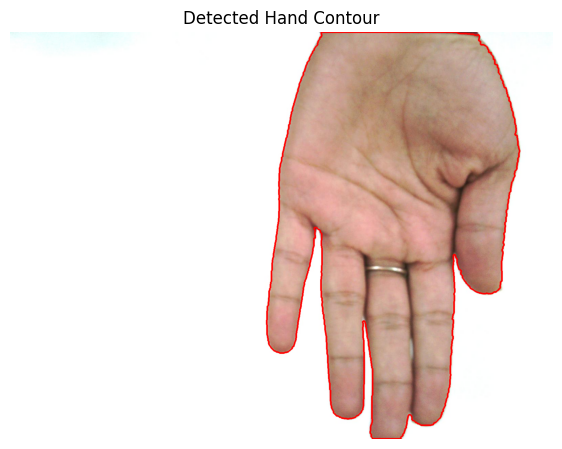

In [58]:
# Draw contour on the image

contour_image = image.copy()

cv2.drawContours(
    contour_image,
    [hand_contour],
    -1,
    (255,0,0),
    3
)

plt.figure(figsize=(7,7))
plt.imshow(contour_image)
plt.title("Detected Hand Contour")
plt.axis("off")
plt.show()

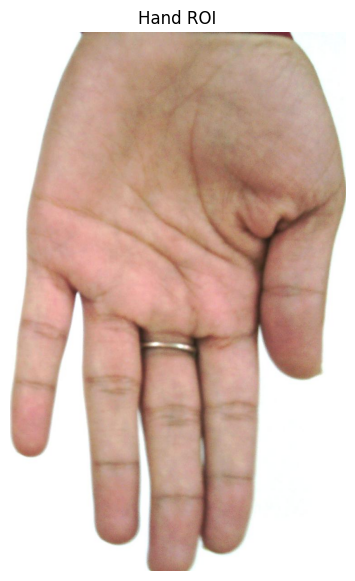

In [59]:
# Crop the detected hand region

x, y, w, h = cv2.boundingRect(hand_contour)

hand_roi = image[y:y+h, x:x+w]

plt.figure(figsize=(7,7))
plt.imshow(hand_roi)
plt.title("Hand ROI")
plt.axis("off")
plt.show()

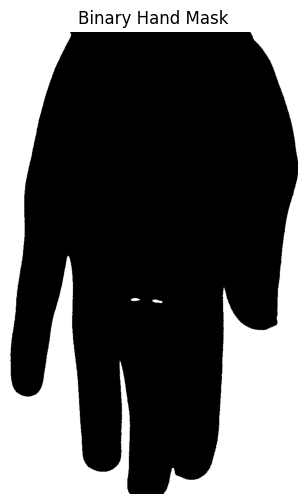

In [60]:
# Create a binary mask for the cropped hand

gray = cv2.cvtColor(hand_roi, cv2.COLOR_RGB2GRAY)

_, binary = cv2.threshold(
    gray,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

plt.figure(figsize=(6,6))
plt.imshow(binary, cmap="gray")
plt.title("Binary Hand Mask")
plt.axis("off")
plt.show()

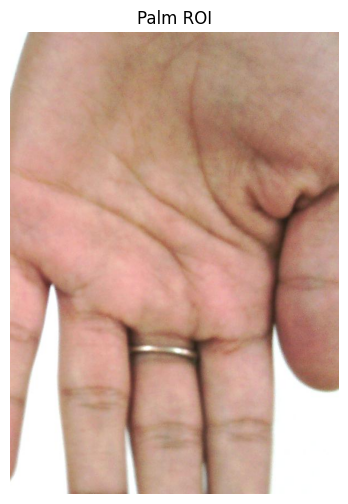

In [61]:
# Remove wrist area to focus on the palm

height, width = binary.shape

top = int(height * 0.10)
bottom = int(height * 0.80)

left = int(width * 0.10)
right = int(width * 0.90)

palm_roi = hand_roi[top:bottom, left:right]

plt.figure(figsize=(6,6))
plt.imshow(palm_roi)
plt.title("Palm ROI")
plt.axis("off")
plt.show()

In [62]:
# Save the extracted palm region

output_path = "/content/palm_roi.jpg"

cv2.imwrite(
    output_path,
    cv2.cvtColor(palm_roi, cv2.COLOR_RGB2BGR)
)

print("Palm ROI saved successfully.")

Palm ROI saved successfully.


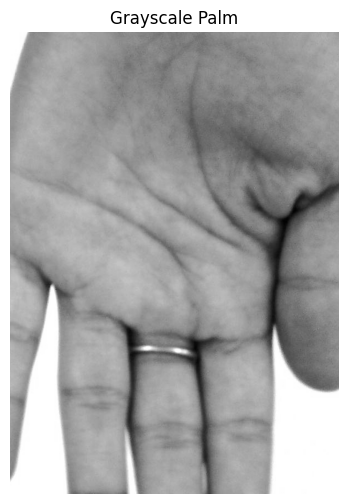

In [63]:
# Convert palm ROI to grayscale

gray = cv2.cvtColor(palm_roi, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(6,6))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Palm")
plt.axis("off")
plt.show()

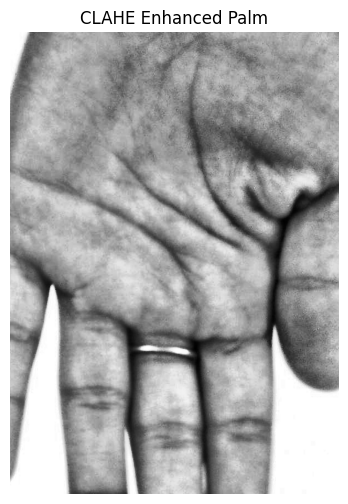

In [64]:
# Improve local contrast using CLAHE

clahe = cv2.createCLAHE(
    clipLimit=3.0,
    tileGridSize=(8,8)
)

enhanced = clahe.apply(gray)

plt.figure(figsize=(6,6))
plt.imshow(enhanced, cmap="gray")
plt.title("CLAHE Enhanced Palm")
plt.axis("off")
plt.show()

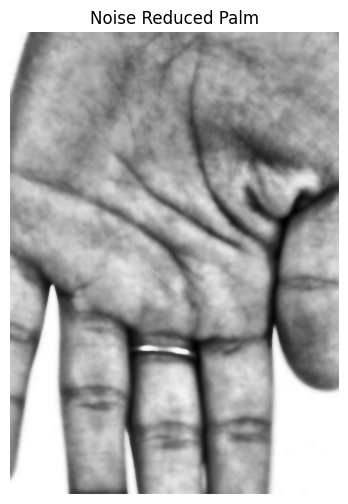

In [65]:
# Reduce noise while preserving palm lines

filtered = cv2.bilateralFilter(
    enhanced,
    d=9,
    sigmaColor=75,
    sigmaSpace=75
)

plt.figure(figsize=(6,6))
plt.imshow(filtered, cmap="gray")
plt.title("Noise Reduced Palm")
plt.axis("off")
plt.show()

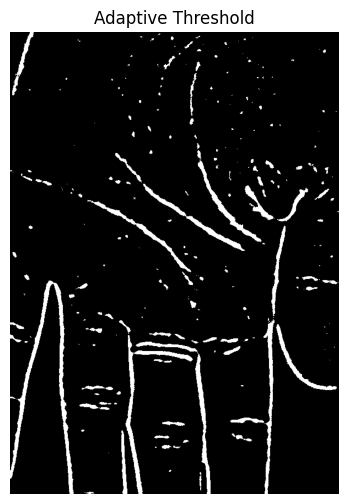

In [66]:
# Highlight palm creases

binary = cv2.adaptiveThreshold(
    filtered,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    21,
    8
)

plt.figure(figsize=(6,6))
plt.imshow(binary, cmap="gray")
plt.title("Adaptive Threshold")
plt.axis("off")
plt.show()

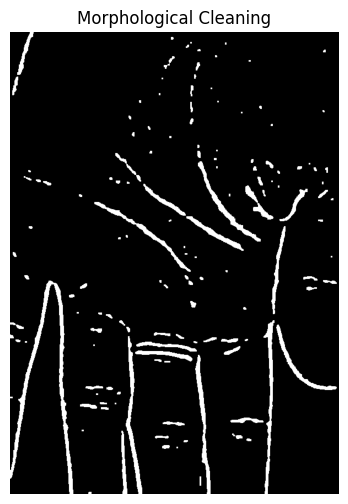

In [67]:
# Remove small noisy regions

kernel = np.ones((3,3), np.uint8)

binary = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    kernel
)

binary = cv2.morphologyEx(
    binary,
    cv2.MORPH_CLOSE,
    kernel
)

plt.figure(figsize=(6,6))
plt.imshow(binary, cmap="gray")
plt.title("Morphological Cleaning")
plt.axis("off")
plt.show()

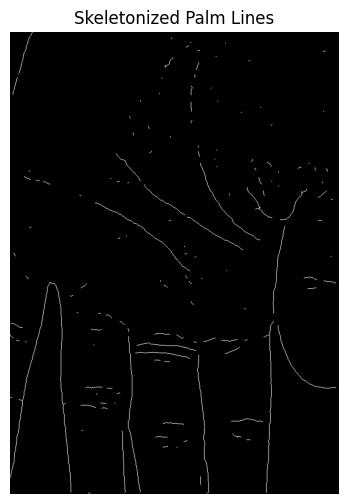

In [68]:
# Convert thick palm lines to one-pixel-wide lines

from skimage.morphology import skeletonize

skeleton = skeletonize(binary > 0)

plt.figure(figsize=(6,6))
plt.imshow(skeleton, cmap="gray")
plt.title("Skeletonized Palm Lines")
plt.axis("off")
plt.show()

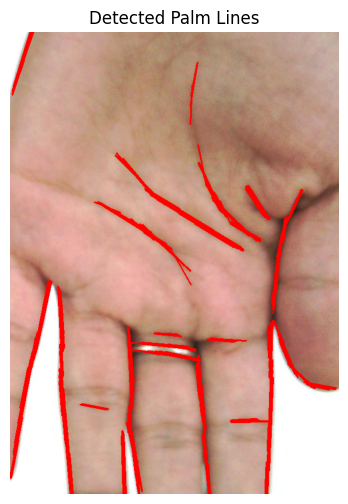

In [69]:
# Detect straight line segments

lines = cv2.HoughLinesP(
    binary,
    rho=1,
    theta=np.pi/180,
    threshold=60,
    minLineLength=40,
    maxLineGap=15
)

line_image = palm_roi.copy()

if lines is not None:

    for line in lines:

        x1, y1, x2, y2 = line[0]

        cv2.line(
            line_image,
            (x1, y1),
            (x2, y2),
            (255, 0, 0),
            2
        )

plt.figure(figsize=(6,6))
plt.imshow(line_image)
plt.title("Detected Palm Lines")
plt.axis("off")
plt.show()

In [70]:
# Keep only longer line segments

filtered_lines = []

if lines is not None:

    for line in lines:

        x1, y1, x2, y2 = line[0]

        length = np.sqrt((x2-x1)**2 + (y2-y1)**2)

        if length > 60:
            filtered_lines.append(line)

print("Detected Major Line Segments :", len(filtered_lines))

Detected Major Line Segments : 137


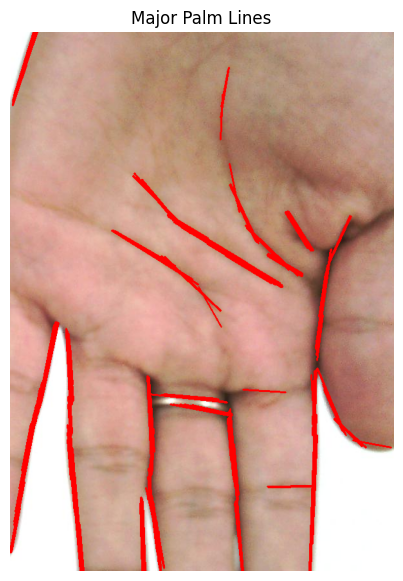

In [71]:
# Draw only the filtered major lines

major_lines = palm_roi.copy()

for line in filtered_lines:

    x1, y1, x2, y2 = line[0]

    cv2.line(
        major_lines,
        (x1, y1),
        (x2, y2),
        (255, 0, 0),
        2
    )

plt.figure(figsize=(7,7))
plt.imshow(major_lines)
plt.title("Major Palm Lines")
plt.axis("off")
plt.show()

In [72]:
# Calculate properties of each detected line

line_data = []

if filtered_lines:

    for line in filtered_lines:

        x1, y1, x2, y2 = line[0]

        length = np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

        angle = np.degrees(
            np.arctan2(y2 - y1, x2 - x1)
        )

        center_x = (x1 + x2) / 2
        center_y = (y1 + y2) / 2

        line_data.append({
            "x1": x1,
            "y1": y1,
            "x2": x2,
            "y2": y2,
            "length": length,
            "angle": angle,
            "center_x": center_x,
            "center_y": center_y
        })

print("Major lines detected:", len(line_data))

Major lines detected: 137


In [73]:
# Store palm dimensions

palm_height, palm_width = palm_roi.shape[:2]

print("Palm Height :", palm_height)
print("Palm Width  :", palm_width)

Palm Height : 840
Palm Width  : 597


In [74]:
# Classify detected lines

classified_lines = {
    "Heart Line": [],
    "Head Line": [],
    "Life Line": [],
    "Fate Line": []
}

for line in line_data:

    y = line["center_y"]
    angle = abs(line["angle"])
    length = line["length"]

    # Heart Line
    if y < palm_height * 0.30 and length > 60:
        classified_lines["Heart Line"].append(line)

    # Head Line
    elif palm_height * 0.30 <= y < palm_height * 0.60 and length > 60:
        classified_lines["Head Line"].append(line)

    # Life Line
    elif y >= palm_height * 0.60 and angle > 30:
        classified_lines["Life Line"].append(line)

    # Fate Line
    if 70 <= angle <= 110 and length > 70:
        classified_lines["Fate Line"].append(line)

In [75]:
# Display classification summary

for line_name in classified_lines:

    print(
        line_name,
        ":",
        len(classified_lines[line_name]),
        "candidate(s)"
    )

Heart Line : 10 candidate(s)
Head Line : 44 candidate(s)
Life Line : 70 candidate(s)
Fate Line : 70 candidate(s)


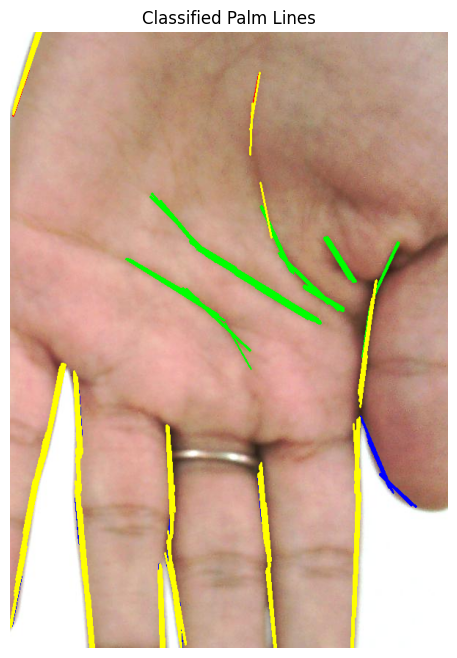

In [76]:
# Draw classified lines using different colors

output = palm_roi.copy()

colors = {
    "Heart Line": (255, 0, 0),
    "Head Line": (0, 255, 0),
    "Life Line": (0, 0, 255),
    "Fate Line": (255, 255, 0)
}

for line_name in classified_lines:

    for line in classified_lines[line_name]:

        cv2.line(
            output,
            (int(line["x1"]), int(line["y1"])),
            (int(line["x2"]), int(line["y2"])),
            colors[line_name],
            2
        )

plt.figure(figsize=(8,8))
plt.imshow(output)
plt.title("Classified Palm Lines")
plt.axis("off")
plt.show()

In [77]:
# Select the longest line in each category

best_lines = {}

for line_name in classified_lines:

    if classified_lines[line_name]:

        best = max(
            classified_lines[line_name],
            key=lambda x: x["length"]
        )

        best_lines[line_name] = best

print(best_lines.keys())

dict_keys(['Heart Line', 'Head Line', 'Life Line', 'Fate Line'])


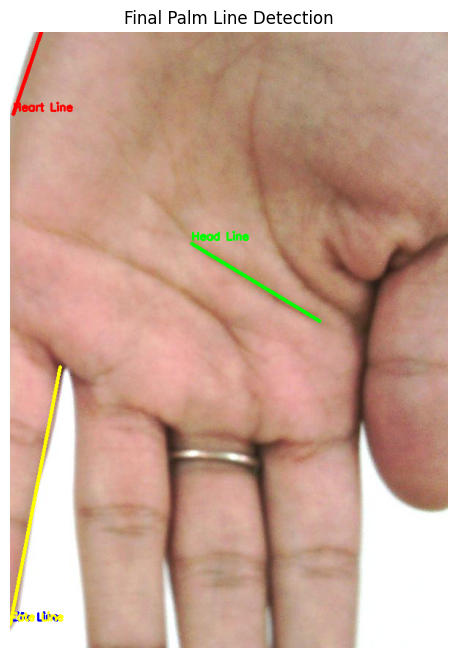

In [78]:
# Draw only the selected major lines

final_output = palm_roi.copy()

for line_name in best_lines:

    line = best_lines[line_name]

    cv2.line(
        final_output,
        (int(line["x1"]), int(line["y1"])),
        (int(line["x2"]), int(line["y2"])),
        colors[line_name],
        3
    )

    cv2.putText(
        final_output,
        line_name,
        (int(line["x1"]), int(line["y1"]) - 5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        colors[line_name],
        2
    )

plt.figure(figsize=(8,8))
plt.imshow(final_output)
plt.title("Final Palm Line Detection")
plt.axis("off")
plt.show()

In [79]:
# Generate a summary of the detected lines

summary = []

for line_name in best_lines:

    line = best_lines[line_name]

    summary.append({
        "Line": line_name,
        "Length": round(line["length"], 2),
        "Angle": round(line["angle"], 2),
        "Center X": round(line["center_x"], 2),
        "Center Y": round(line["center_y"], 2)
    })

summary_df = pd.DataFrame(summary)

summary_df

,Line,Length,Angle,Center X,Center Y
0,Heart Line,118.27,-71.26,23.0,56.0
1,Head Line,204.60,31.20,334.5,341.0
2,Life Line,357.53,-79.04,34.0,631.5
3,Fate Line,357.53,-79.04,34.0,631.5
